In [ ]:
!pip -q install tiktoken nltk datasets tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, math, copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass
from contextlib import nullcontext
from tqdm.auto import tqdm

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

import tiktoken

# tokenizer
enc = tiktoken.get_encoding("gpt2")

# device
device = "cuda" if torch.cuda.is_available() else "cpu"
device_type = "cuda" if device.startswith("cuda") else "cpu"

torch.manual_seed(42)

In [ ]:
class LayerNorm(nn.Module):
    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None
    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5)

class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.flash = hasattr(F, 'scaled_dot_product_attention')
        if not self.flash:
            self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                       .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        if self.flash:
            y = F.scaled_dot_product_attention(
                q, k, v,
                attn_mask=None,
                dropout_p=self.attn_dropout.p if self.training else 0.0,
                is_causal=True
            )
        else:
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v

        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)
    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1 = LayerNorm(config.n_embd, config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln2 = LayerNorm(config.n_embd, config.bias)
        self.mlp = MLP(config)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int
    vocab_size: int
    n_layer: int
    n_head: int
    n_embd: int
    dropout: float = 0.0
    bias: bool = True

class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte=nn.Embedding(config.vocab_size, config.n_embd),
            wpe=nn.Embedding(config.block_size, config.n_embd),
            drop=nn.Dropout(config.dropout),
            h=nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f=LayerNorm(config.n_embd, config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight

        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        device = idx.device
        b, t = idx.size()
        assert t <= self.config.block_size
        pos = torch.arange(0, t, dtype=torch.long, device=device)

        tok_emb = self.transformer.wte(idx)
        pos_emb = self.transformer.wpe(pos)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1),
                ignore_index=-1
            )
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float("inf")
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

    def log_probs(self, idx, targets):
        logits, _ = self(idx)
        logp = F.log_softmax(logits, dim=-1)
        out = logp.gather(-1, targets.unsqueeze(-1)).squeeze(-1)
        return out

In [ ]:
config = GPTConfig(
    vocab_size=50257,
    block_size=128,
    n_layer=6,
    n_head=6,
    n_embd=384,
    dropout=0.1,
    bias=True
)

model = GPT(config).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/AML_Final_Project/best_model_params.pt", map_location=device))
model.eval()

print("Model loaded")

Model loaded


# Sanity check

In [ ]:
prompt_text = "Once upon a time"
prompt_ids = torch.tensor(enc.encode_ordinary(prompt_text), device=device).unsqueeze(0)

out = model.generate(prompt_ids, max_new_tokens=120, temperature=1.0, top_k=40)
print(enc.decode(out[0].tolist()))

Once upon a time, there was a little girl named Lily. She loved to paint and paint it she could shine on the wall when she grew her favorite color. One day, she went to bed and looked in the mirror. It was black and had a pretty face on it. 

Lily started to feel something. It felt like she had made and started to shake. But then, a big wind blew back from Lily's finger and said, "Don't worry, Lily. I can take a shower and you can take it back." 

Lily nodded and said, "Yes,


In [ ]:
try:
    sid = SentimentIntensityAnalyzer()
except LookupError:
    nltk.download("vader_lexicon")
    sid = SentimentIntensityAnalyzer()

def sentiment_reward(token_batch):
    rewards = torch.zeros(token_batch.size(0), device=token_batch.device, dtype=torch.float32)
    for i in range(token_batch.size(0)):
        text = enc.decode(token_batch[i].tolist())
        rewards[i] = sid.polarity_scores(text)["compound"]
    return rewards

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
ref_model = copy.deepcopy(model).to(device)
ref_model.eval()
for p in ref_model.parameters():
    p.requires_grad_(False)

# RL hyperparams (your "happy" style: PG + KL)
rl_batch_size = 64
num_iters = 300
gen_new_tokens = 128   # how long to sample during RL
temperature = 1.0
top_k = 40

learning_rate = 1e-5
grad_norm_clip = 1.0
kl_beta = 0.1

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, betas=(0.9, 0.95))
model.train()

# prompt batch: same prefix for all sequences
base_prompt = "Once upon a time"
base_prompt_ids = torch.tensor(enc.encode_ordinary(base_prompt), device=device).unsqueeze(0)
prompt = base_prompt_ids.repeat(rl_batch_size, 1)  # (B, Tprompt)

print("RL setup complete.")

RL setup complete.


In [ ]:
from tqdm.auto import trange

reward_log = []
kl_log = []

def crop_for_logprobs(seq, block_size):
    # seq: (B, T)
    # returns last block_size tokens
    if seq.size(1) <= block_size:
        return seq
    return seq[:, -block_size:]


for it in trange(num_iters, desc="RL alignment"):
    with torch.no_grad():
        model.eval()
        completion = model.generate(
            prompt,
            max_new_tokens=gen_new_tokens,
            temperature=temperature,
            top_k=top_k
        )
        model.train()

        # rewards: (B,)
        rewards = sentiment_reward(completion)

        # ---- FIX IS HERE ----
        comp_in = crop_for_logprobs(completion[:, :-1], config.block_size)
        comp_tg = crop_for_logprobs(completion[:, 1:],  config.block_size)

        ref_logp = ref_model.log_probs(comp_in, comp_tg)  # (B, T')
    # ----------------------

    logp = model.log_probs(comp_in, comp_tg)              # (B, T')

    kl = logp - ref_logp                                  # (B, T')

    # broadcast reward over time + KL penalty
    score = rewards[:, None] - kl_beta * kl
    score = score.detach()

    # vanilla policy gradient loss
    loss = -(score * logp).mean()

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_norm_clip)
    optimizer.step()

    reward_log.append(rewards.mean().item())
    kl_log.append(kl.mean().item())

    if it % 10 == 0:
        print(
            f"iter {it:04d} | reward {reward_log[-1]:+.4f} | "
            f"kl {kl_log[-1]:+.4f} | loss {loss.item():.4f}"
        )

    if it % 50 == 0:
        model.eval()
        sample = model.generate(
            base_prompt_ids,
            max_new_tokens=120,
            temperature=1.0,
            top_k=40
        )
        print("\n[SAMPLE]\n", enc.decode(sample[0].tolist()), "\n")
        model.train()


RL alignment:   0%|          | 0/300 [00:00<?, ?it/s]

iter 0000 | reward +0.6487 | kl -0.1203 | loss 1.1104

[SAMPLE]
 Once upon a time there was a little girl called Jane. She had a big, thick truck with two things on it. 

One day, Jane was playing in her backyard when she saw a big, shiny thing on the ground. It was big and round! She wanted to give it back. 

Jane was sad and did not know what to do. She ran into the dirt and watched. It was a great idea.

So Jane and her mom walked inside the room - where the car had come from under!

The truck was so excited that everyone had found. They had 

iter 0010 | reward +0.8862 | kl +0.0062 | loss 1.2236
iter 0020 | reward +0.9052 | kl +0.0828 | loss 1.1756
iter 0030 | reward +0.9473 | kl +0.1317 | loss 1.1573
iter 0040 | reward +0.9226 | kl +0.1765 | loss 1.0588
iter 0050 | reward +0.9497 | kl +0.2114 | loss 1.0655

[SAMPLE]
 Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine and explore the world around him. One day, they found a beautiful bird

Saved aligned model to: tinystories_pos_aligned.pt


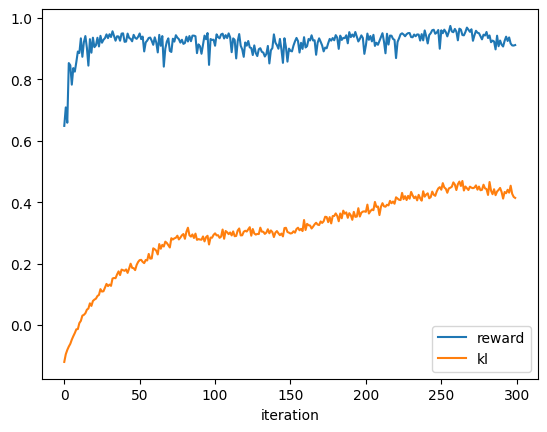

In [ ]:
save_path = "tinystories_pos_aligned.pt"
torch.save(model.state_dict(), save_path)
print("Saved aligned model to:", save_path)

import matplotlib.pyplot as plt

plt.plot(reward_log, label="reward")
plt.plot(kl_log, label="kl")
plt.legend()
plt.xlabel("iteration")
plt.show()

# Evaluation

In [ ]:
eval_prompts = [
    "He was angry because",
    "She felt very sad when",
    "Nobody wanted to help",
    "The boy was scared and",
    "Everything went wrong when",
]

num_samples_per_prompt = 5
gen_new_tokens = 120
temperature = 1.0
top_k = 40

In [ ]:
@torch.no_grad()
def generate_and_score(model, prompts):
    model.eval()
    rewards = []
    texts = []

    for prompt in tqdm(prompts, desc="Evaluating"):
        prompt_ids = torch.tensor(
            enc.encode_ordinary(prompt),
            device=device
        ).unsqueeze(0)

        for _ in range(num_samples_per_prompt):
            out = model.generate(
                prompt_ids,
                max_new_tokens=gen_new_tokens,
                temperature=temperature,
                top_k=top_k
            )

            text = enc.decode(out[0].tolist())
            reward = sentiment_reward(out).item()

            rewards.append(reward)
            texts.append(text)

    return np.array(rewards), texts

In [ ]:
print("\n=== Evaluating BASE (reference) model ===")
base_rewards, base_texts = generate_and_score(ref_model, eval_prompts)

print("\n=== Evaluating RL-aligned model ===")
rl_rewards, rl_texts = generate_and_score(model, eval_prompts)


=== Evaluating BASE (reference) model ===


Evaluating:   0%|          | 0/5 [00:00<?, ?it/s]


=== Evaluating RL-aligned model ===


Evaluating:   0%|          | 0/5 [00:00<?, ?it/s]

In [ ]:
def summarize(name, rewards):
    print(f"\n{name} reward stats")
    print(f"  mean: {rewards.mean():.4f}")
    print(f"  std : {rewards.std():.4f}")
    print(f"  min : {rewards.min():.4f}")
    print(f"  max : {rewards.max():.4f}")

summarize("BASE", base_rewards)
summarize("RL  ", rl_rewards)


BASE reward stats
  mean: 0.5236
  std : 0.6477
  min : -0.9686
  max : 0.9893

RL   reward stats
  mean: 0.6643
  std : 0.4963
  min : -0.9362
  max : 0.9797


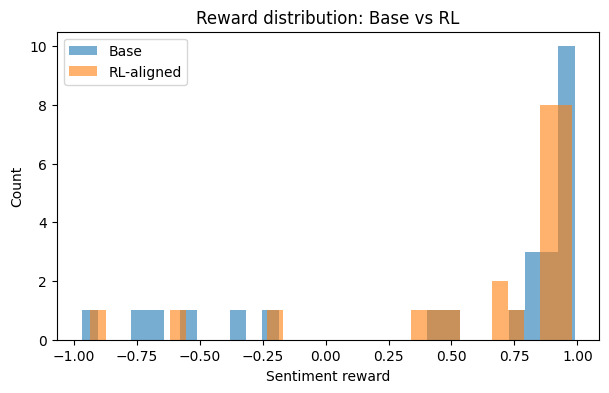

In [ ]:
plt.figure(figsize=(7,4))
plt.hist(base_rewards, bins=30, alpha=0.6, label="Base")
plt.hist(rl_rewards, bins=30, alpha=0.6, label="RL-aligned")
plt.xlabel("Sentiment reward")
plt.ylabel("Count")
plt.legend()
plt.title("Reward distribution: Base vs RL")
plt.show()


In [ ]:
import random

print("\n=== SIDE-BY-SIDE SAMPLES ===\n")

idxs = random.sample(range(len(base_texts)), k=5)
for i, idx in enumerate(idxs):
    print(f"\n--- SAMPLE {i+1} ---")

    print("\n[BASE]")
    print(base_texts[idx][:800])

    print("\n[RL]")
    print(rl_texts[idx][:800])

    print("\n---------------------------")


=== SIDE-BY-SIDE SAMPLES ===


--- SAMPLE 1 ---

[BASE]
She felt very sad when she found her dress. It was pink and had a pretty dress. She put it on the clothes and drove it to her house.

She walked around the room and found a beautiful butterfly in the garden. She thanked her mom and asked her where she had gave it a hug. Her mom smiled and said, "Now I'm a great butterfly. Let's play the park together and see it and see if you can. Do you want to try it off?"

The butterfly smiled and said, "Yes! Let's play it!" She ran around the park and had a fun

[RL]
She felt very sad when she was on a walk in the woods near a big forest. Suddenly, she heard a voice. It was her mommy, who was very curious. She asked her mommy if Lily could go inside and see it.

Lily replied, "No, Lily. It's too dark for you."

Her mommy said, "I want to go inside and see what is inside?" 

Lily replied, "Of course we can go to the forest and see what is inside?" 

They walked in the forest and saw a big, yel